In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# TGF Time Series - Data

In [2]:
df = pd.read_excel("./data/TGF N-prod data.xlsx", sheet_name = 1, header = 0)
df.head()

,Run,Process Time [h],agitation speed [rpm],air overlay rate [L/min],daily ammonia concentration [mg/L],daily bioreactor weight [kg],daily cell viability [%],daily glucose concentration [mg/L],daily glutamate concentration [mg/L],daily igg concentration [g/L],...,dissolved oxygen 1 [%],dissolved oxygen 2 [%],feed a percentage [%],feed a quantity [kg],feed b percentage [%],feed b quantity [kg],glucose feed quantity [kg],ph online probe 1 [pH],ph online probe 2 [pH],sparger air flow [L/min]
0,GA001_TGFBxPD1 N STR2000L_1003472,70.585556,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.17,NaN,NaN
1,GA001_TGFBxPD1 N STR2000L_1003472,70.588056,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.19,NaN
2,GA001_TGFBxPD1 N STR2000L_1003472,70.817222,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,GA001_TGFBxPD1 N STR2000L_1003472,70.819444,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,GA001_TGFBxPD1 N STR2000L_1003472,70.821667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# TGF Time Series - Features

In [3]:
feat = [
    "daily pCO2 offline [mmHg]",
    "daily ammonia concentration [mg/L]",
    "sparger air flow [L/min]",
    "daily ph offline [dimensionless]",
    "ph online probe 1 [pH]",
    "ph online probe 2 [pH]",
]
feat = feat + [col for col in df.columns[2:] if col not in feat]

In [4]:
uniq_runs = sorted(df["Run"].unique())
len(uniq_runs)

10

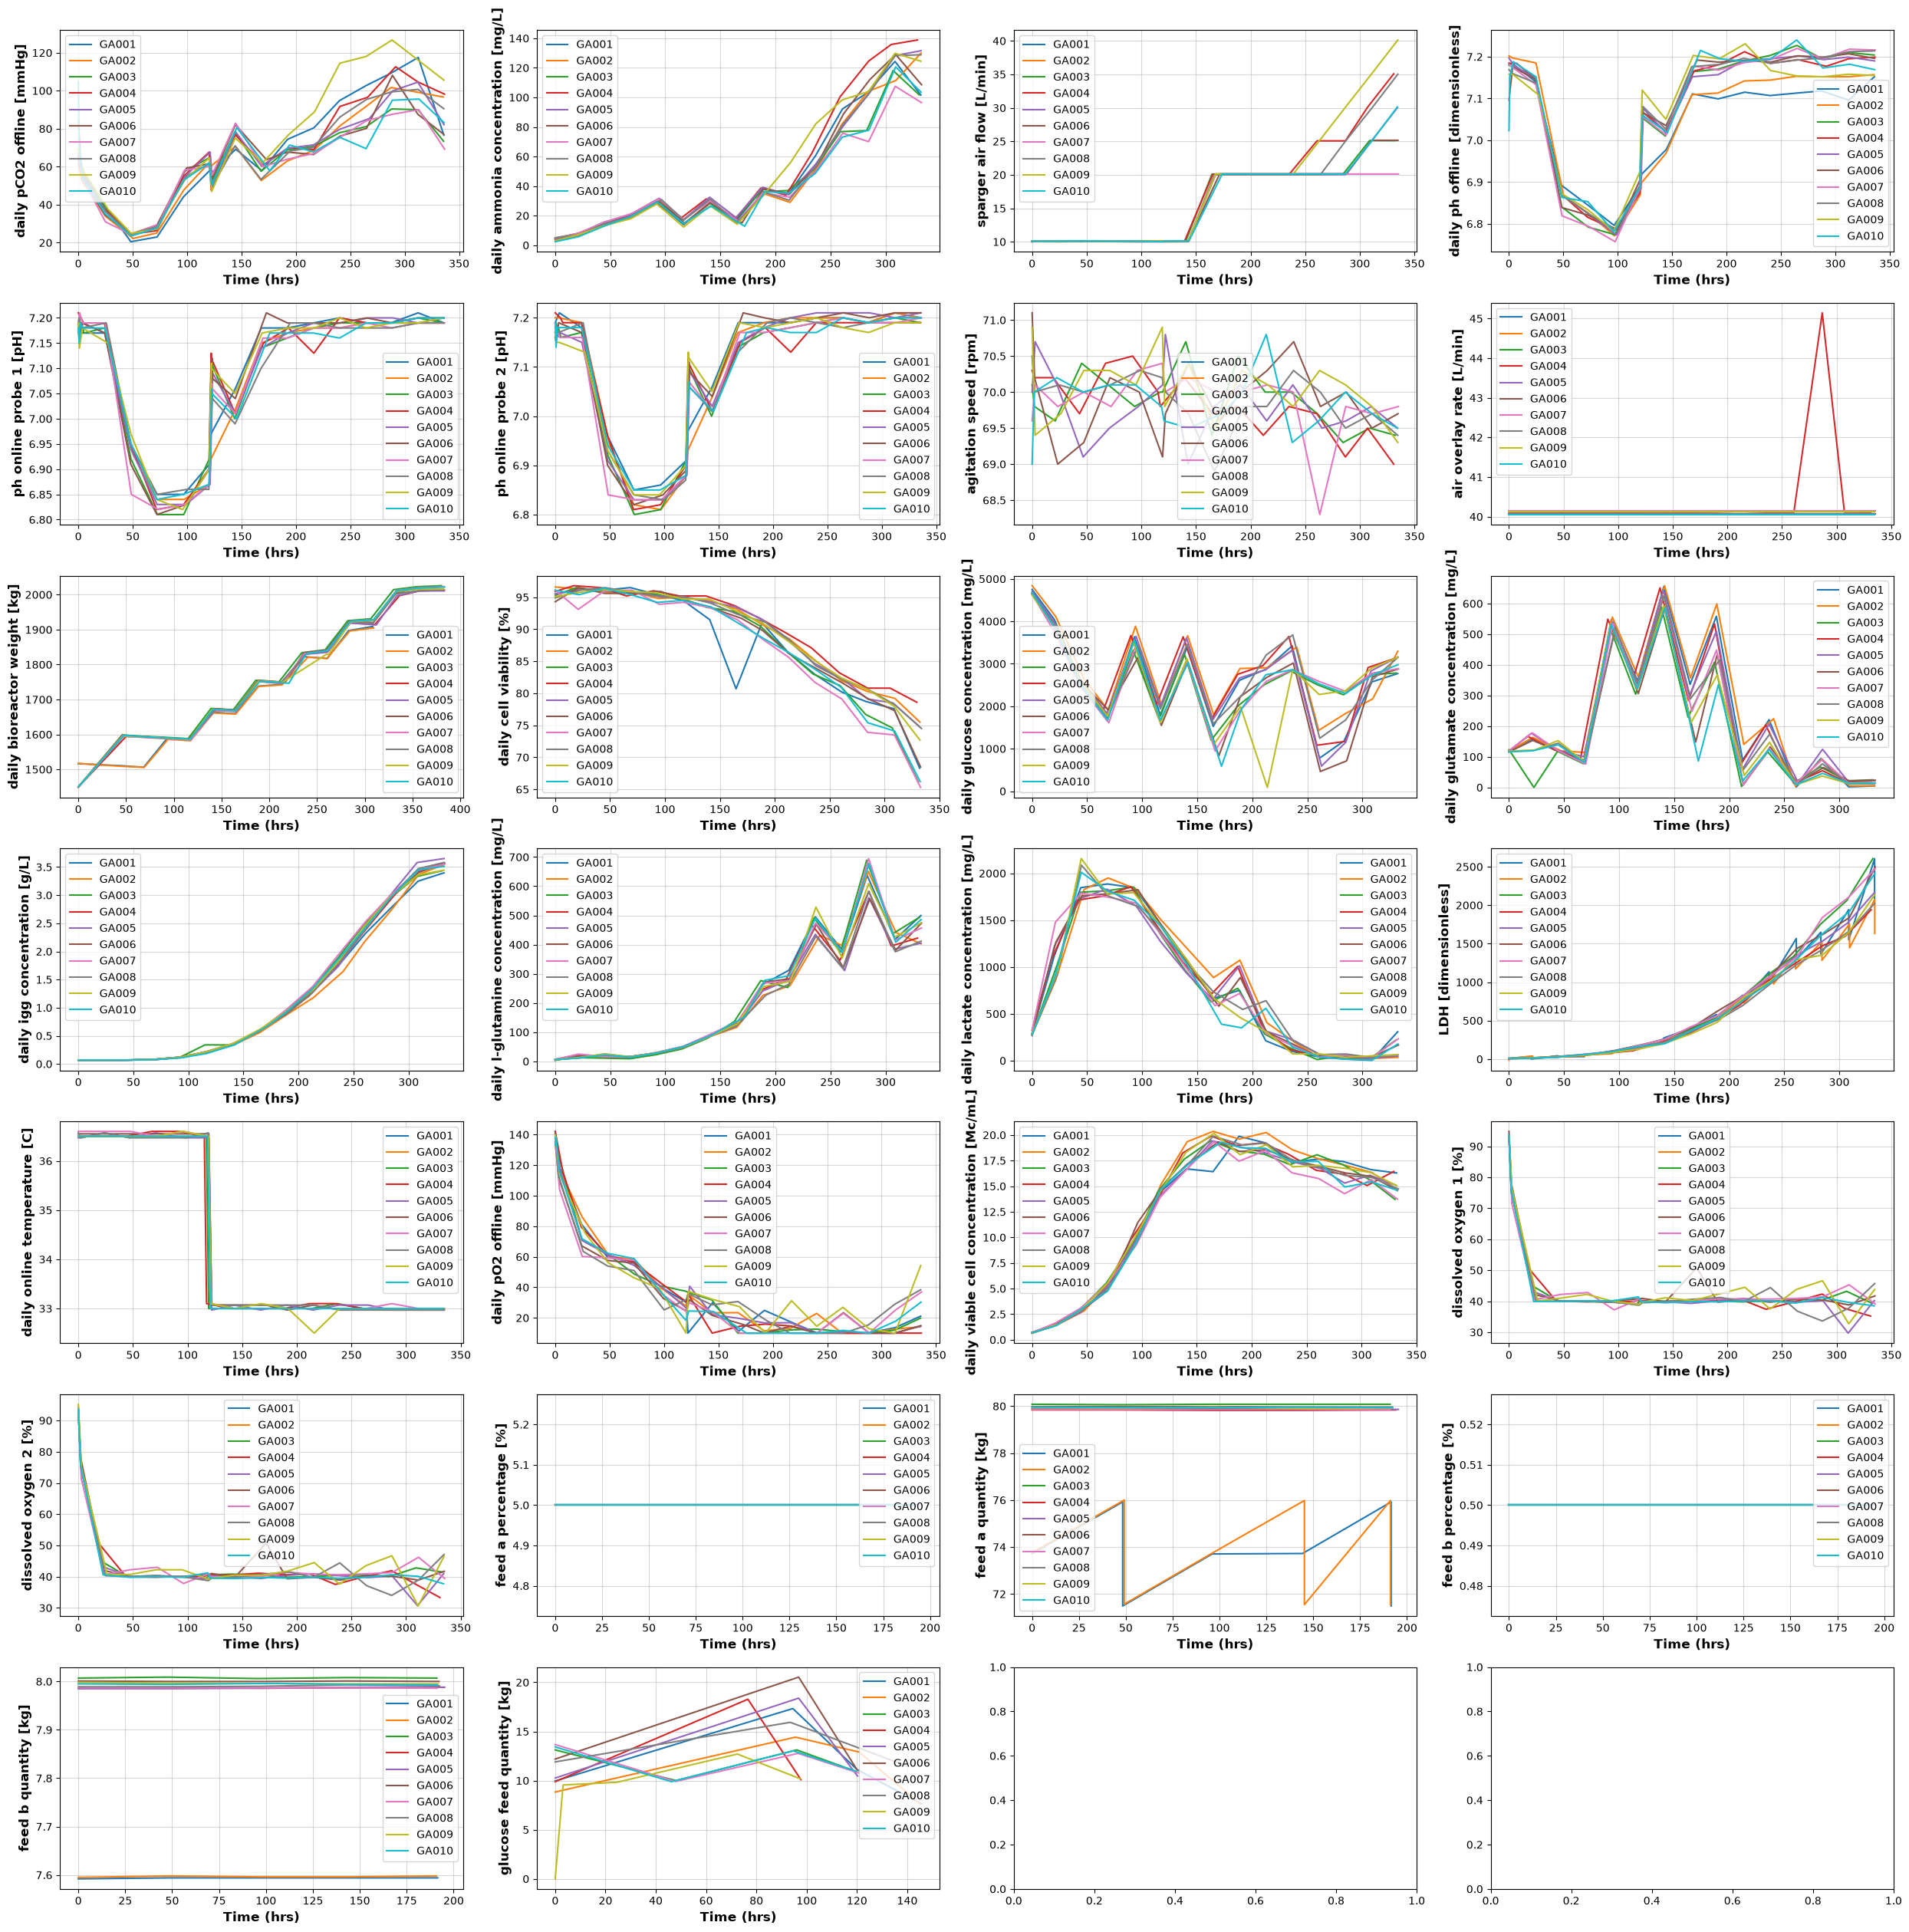

In [5]:
fig, axs = plt.subplots(7, 4, figsize = (25, 25))

for run_idx, run in enumerate(uniq_runs):
    for idx, indicator in enumerate(feat):
        
        row_idx = idx // 4
        col_idx = idx % 4

        ax = axs[row_idx][col_idx]
        
        sub_df = df[df["Run"] == run][["Process Time [h]", indicator]].copy()
        sub_df = sub_df[~sub_df[indicator].isna()]
        ax.plot(sub_df["Process Time [h]"] - sub_df["Process Time [h]"].min(), sub_df[indicator], label = run.split("_")[0])

        if run_idx == 9:
            # ax.set_title(indicator)
            ax.set_xlabel("Time (hrs)", fontsize=12, fontweight='bold')
            ax.set_ylabel(indicator, fontsize=12, fontweight='bold')
            ax.legend()
            ax.grid(alpha = 0.5)

fig.tight_layout()

# TGF Time Series - Records Analysis

In [6]:
time_series = pd.read_excel("./data/TGF N-prod data.xlsx", sheet_name = 1, header = 0)

In [7]:
uniq_runs = time_series.Run.unique()

In [8]:
run = uniq_runs[1]
print(f"Run: {run}")
time_series[time_series.Run == run][feat].count()

Run: GA002_TGFBxPD1   N STR2000L_1003601


daily pCO2 offline [mmHg]                  17
daily ammonia concentration [mg/L]         15
sparger air flow [L/min]                    0
daily ph offline [dimensionless]           17
ph online probe 1 [pH]                     17
ph online probe 2 [pH]                     17
agitation speed [rpm]                       0
air overlay rate [L/min]                    0
daily bioreactor weight [kg]               14
daily cell viability [%]                   15
daily glucose concentration [mg/L]         15
daily glutamate concentration [mg/L]       15
daily igg concentration [g/L]              15
daily l-glutamine concentration [mg/L]     15
daily lactate concentration [mg/L]         15
LDH [dimensionless]                        30
daily online temperature [C]                0
daily pO2 offline [mmHg]                   17
daily viable cell concentration [Mc/mL]    15
dissolved oxygen 1 [%]                      0
dissolved oxygen 2 [%]                      0
feed a percentage [%]             

In [9]:
time_series["Run"] = time_series["Run"].str.split("_").str[0]
time_series.groupby("Run").count()

,Process Time [h],agitation speed [rpm],air overlay rate [L/min],daily ammonia concentration [mg/L],daily bioreactor weight [kg],daily cell viability [%],daily glucose concentration [mg/L],daily glutamate concentration [mg/L],daily igg concentration [g/L],daily l-glutamine concentration [mg/L],...,dissolved oxygen 1 [%],dissolved oxygen 2 [%],feed a percentage [%],feed a quantity [kg],feed b percentage [%],feed b quantity [kg],glucose feed quantity [kg],ph online probe 1 [pH],ph online probe 2 [pH],sparger air flow [L/min]
Run,,,,,,,,,,,,,,,,,,,,,
GA001,267,0,0,15,14,15,15,15,15,15,...,0,0,5,7,5,5,4,17,17,0
GA002,266,0,0,15,14,15,15,15,15,15,...,0,0,5,8,5,5,4,17,17,0
GA003,382,17,17,15,17,15,15,15,15,15,...,17,17,5,5,5,5,4,19,19,17
GA004,381,17,17,15,17,15,15,15,15,15,...,17,17,5,5,5,5,3,19,19,17
GA005,381,17,17,15,17,15,15,15,15,15,...,17,17,5,5,5,5,3,19,19,17
GA006,381,17,17,15,17,15,15,15,15,15,...,17,17,5,5,5,5,3,19,19,17
GA007,382,17,17,15,17,15,15,15,15,15,...,17,17,5,5,5,5,4,19,19,17
GA008,381,17,17,15,17,15,15,15,15,15,...,17,17,5,5,5,5,3,19,19,17
GA009,383,17,17,15,17,15,15,15,15,15,...,17,17,5,5,5,5,5,19,19,17


### Per-run Records

For every run, each feature is condensed to its non-empty records and described by three
columns: the value, the process time at which it was recorded, and the elapsed time since
the previous record of that same feature (`NaN` for the first one).

Features are sampled at different times, so their record counts differ. The columns are
aligned on a positional index and the shorter ones are padded with `NaN`.

In [10]:
TIME_COL = "Process Time [h]"
TIME_SUFFIX = "_record_time_[h]"
DIFF_SUFFIX = "_time_difference_[h]"

In [11]:
def run_records(run_df, features, time_col = TIME_COL):
    blocks = []
    for feature in features:
        records = run_df.loc[run_df[feature].notna(), [time_col, feature]].sort_values(time_col)
        times = records[time_col].to_numpy(dtype = float)
        start_time = times[0] if times.size != 0 else np.nan
        blocks.append(pd.DataFrame({
            feature: records[feature].to_numpy(),
            f"{feature}{TIME_SUFFIX}": times,
            f"{feature}{DIFF_SUFFIX}": np.diff(times, prepend = start_time),
        }))
    return pd.concat(blocks, axis = 1)

In [12]:
uniq_runs = sorted(df["Run"].unique())

run_dfs = {run: run_records(df[df["Run"] == run], feat) for run in uniq_runs}

pd.Series({run: run_df.shape for run, run_df in run_dfs.items()})

GA001_TGFBxPD1   N STR2000L_1003472    (30, 78)
GA002_TGFBxPD1   N STR2000L_1003601    (30, 78)
GA003_TGFBxPD1   N STR2000L_1005331    (19, 78)
GA004_TGFBxPD1   N STR2000L_1005425    (19, 78)
GA005_TGFBxPD1   N STR2000L_1005446    (19, 78)
GA006_TGFBxPD1   N STR2000L_1005471    (19, 78)
GA007_TGFBxPD1   N STR2000L_1005542    (19, 78)
GA008_TGFBxPD1   N STR2000L_1005743    (19, 78)
GA009_TGFBxPD1   N STR2000L_1005751    (19, 78)
GA010_TGFBxPD1   N STR2000L_1005752    (20, 78)
dtype: object

In [13]:
pd.set_option('display.max_columns', None)

run = uniq_runs[0]
print(f"Run: {run}")
run_dfs[run]

Run: GA001_TGFBxPD1   N STR2000L_1003472


,daily pCO2 offline [mmHg],daily pCO2 offline [mmHg]_record_time_[h],daily pCO2 offline [mmHg]_time_difference_[h],daily ammonia concentration [mg/L],daily ammonia concentration [mg/L]_record_time_[h],daily ammonia concentration [mg/L]_time_difference_[h],sparger air flow [L/min],sparger air flow [L/min]_record_time_[h],sparger air flow [L/min]_time_difference_[h],daily ph offline [dimensionless],daily ph offline [dimensionless]_record_time_[h],daily ph offline [dimensionless]_time_difference_[h],ph online probe 1 [pH],ph online probe 1 [pH]_record_time_[h],ph online probe 1 [pH]_time_difference_[h],ph online probe 2 [pH],ph online probe 2 [pH]_record_time_[h],ph online probe 2 [pH]_time_difference_[h],agitation speed [rpm],agitation speed [rpm]_record_time_[h],agitation speed [rpm]_time_difference_[h],air overlay rate [L/min],air overlay rate [L/min]_record_time_[h],air overlay rate [L/min]_time_difference_[h],daily bioreactor weight [kg],daily bioreactor weight [kg]_record_time_[h],daily bioreactor weight [kg]_time_difference_[h],daily cell viability [%],daily cell viability [%]_record_time_[h],daily cell viability [%]_time_difference_[h],daily glucose concentration [mg/L],daily glucose concentration [mg/L]_record_time_[h],daily glucose concentration [mg/L]_time_difference_[h],daily glutamate concentration [mg/L],daily glutamate concentration [mg/L]_record_time_[h],daily glutamate concentration [mg/L]_time_difference_[h],daily igg concentration [g/L],daily igg concentration [g/L]_record_time_[h],daily igg concentration [g/L]_time_difference_[h],daily l-glutamine concentration [mg/L],daily l-glutamine concentration [mg/L]_record_time_[h],daily l-glutamine concentration [mg/L]_time_difference_[h],daily lactate concentration [mg/L],daily lactate concentration [mg/L]_record_time_[h],daily lactate concentration [mg/L]_time_difference_[h],LDH [dimensionless],LDH [dimensionless]_record_time_[h],LDH [dimensionless]_time_difference_[h],daily online temperature [C],daily online temperature [C]_record_time_[h],daily online temperature [C]_time_difference_[h],daily pO2 offline [mmHg],daily pO2 offline [mmHg]_record_time_[h],daily pO2 offline [mmHg]_time_difference_[h],daily viable cell concentration [Mc/mL],daily viable cell concentration [Mc/mL]_record_time_[h],daily viable cell concentration [Mc/mL]_time_difference_[h],dissolved oxygen 1 [%],dissolved oxygen 1 [%]_record_time_[h],dissolved oxygen 1 [%]_time_difference_[h],dissolved oxygen 2 [%],dissolved oxygen 2 [%]_record_time_[h],dissolved oxygen 2 [%]_time_difference_[h],feed a percentage [%],feed a percentage [%]_record_time_[h],feed a percentage [%]_time_difference_[h],feed a quantity [kg],feed a quantity [kg]_record_time_[h],feed a quantity [kg]_time_difference_[h],feed b percentage [%],feed b percentage [%]_record_time_[h],feed b percentage [%]_time_difference_[h],feed b quantity [kg],feed b quantity [kg]_record_time_[h],feed b quantity [kg]_time_difference_[h],glucose feed quantity [kg],glucose feed quantity [kg]_record_time_[h],glucose feed quantity [kg]_time_difference_[h]
0,65.5,70.819444,0.000000,3.913,75.091944,0.000000,NaN,NaN,NaN,7.184,70.817222,0.000000,7.17,70.585556,0.000000,7.19,70.588056,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,1516.58,75.380833,0.000000,95.5,74.819167,0.000000,4752.37,75.080278,0.000000,118.29,75.086111,0.000000,0.067,75.094167,0.000000,3.68,75.084167,0.000000,294.10,75.088889,0.000000,0.0,75.101944,0.000000,NaN,NaN,NaN,142.1,70.821667,0.000000,0.71,74.814167,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,5.0,145.467500,0.000000,73.723296,145.467222,0.000000,0.5,146.450556,0.000000,7.592,146.450556,0.000000,9.960,264.276111,0.000000
1,55.1,74.794444,3.975000,6.571,95.286389,20.194444,NaN,NaN,NaN,7.182,74.792222,3.975000,7.17,74.415000,3.829444,7.21,74.415278,3.827222,NaN,NaN,NaN,NaN,NaN,NaN,1513.44,95.887222,20.506389,96.2,94.876667,20.057500,4043.74,95.276944,20.196667,157.00,95.281389,20.195278,0.068,95.290556,20.196389,18.49,95.279167,20.195000,1120.26,95.284167,20

### Reducing records by day

In [14]:
MIN_DAY_DURATION = 15 # Time in hours
MAX_DAY_DURATION = np.inf # Time in hours

In [15]:
def reduce_records(run_df, features, diff_suffix):
    blocks = []
    for feature in features:

        diff_time_col = f"{feature}{diff_suffix}"
        records = run_df.loc[run_df[feature].notna(), [feature, diff_time_col]]
        
        next_time_diff = records[diff_time_col].shift(-1)
        valid_records = next_time_diff.between(MIN_DAY_DURATION, MAX_DAY_DURATION) | next_time_diff.isna()

        blocks.append(pd.DataFrame({feature: records[feature][valid_records].to_numpy()}))
    return pd.concat(blocks, axis = 1)

In [16]:
uniq_runs = sorted(df["Run"].unique())

reduced_run_dfs = {run: reduce_records(run_df, feat, DIFF_SUFFIX) for run, run_df in run_dfs.items()}

pd.Series({run: run_df.shape for run, run_df in reduced_run_dfs.items()})

GA001_TGFBxPD1   N STR2000L_1003472    (15, 26)
GA002_TGFBxPD1   N STR2000L_1003601    (15, 26)
GA003_TGFBxPD1   N STR2000L_1005331    (16, 26)
GA004_TGFBxPD1   N STR2000L_1005425    (16, 26)
GA005_TGFBxPD1   N STR2000L_1005446    (16, 26)
GA006_TGFBxPD1   N STR2000L_1005471    (16, 26)
GA007_TGFBxPD1   N STR2000L_1005542    (16, 26)
GA008_TGFBxPD1   N STR2000L_1005743    (16, 26)
GA009_TGFBxPD1   N STR2000L_1005751    (15, 26)
GA010_TGFBxPD1   N STR2000L_1005752    (16, 26)
dtype: object

### Analysis of the records reduced by day

In [17]:
run = uniq_runs[2]
print(f"Run: {run}, Shape: {reduced_run_dfs[run].shape}")

Run: GA003_TGFBxPD1   N STR2000L_1005331, Shape: (16, 26)


In [18]:
reduced_run_dfs[run].count()

daily pCO2 offline [mmHg]                  15
daily ammonia concentration [mg/L]         15
sparger air flow [L/min]                   15
daily ph offline [dimensionless]           15
ph online probe 1 [pH]                     15
ph online probe 2 [pH]                     15
agitation speed [rpm]                      15
air overlay rate [L/min]                   15
daily bioreactor weight [kg]               16
daily cell viability [%]                   15
daily glucose concentration [mg/L]         15
daily glutamate concentration [mg/L]       15
daily igg concentration [g/L]              15
daily l-glutamine concentration [mg/L]     15
daily lactate concentration [mg/L]         15
LDH [dimensionless]                        15
daily online temperature [C]               15
daily pO2 offline [mmHg]                   15
daily viable cell concentration [Mc/mL]    15
dissolved oxygen 1 [%]                     15
dissolved oxygen 2 [%]                     15
feed a percentage [%]             

In [19]:
run_dfs[run][["daily bioreactor weight [kg]", "daily bioreactor weight [kg]_record_time_[h]", "daily bioreactor weight [kg]_time_difference_[h]"]]

,daily bioreactor weight [kg],daily bioreactor weight [kg]_record_time_[h],daily bioreactor weight [kg]_time_difference_[h]
0,1450.192,31.601389,0.000000
1,1599.440,77.852222,46.250833
2,1598.450,78.778333,0.926111
3,1594.280,101.477500,22.699167
4,1591.800,122.960000,21.482500
5,1588.100,146.592500,23.632500
6,1674.460,170.598889,24.006389
7,1670.310,193.863889,23.265000
8,1754.810,217.390000,23.526111
9,1750.040,241.633333,24.243333


In [20]:
reduced_run_dfs[run][["daily bioreactor weight [kg]"]]

,daily bioreactor weight [kg]
0,1450.192
1,1598.450
2,1594.280
3,1591.800
4,1588.100
5,1674.460
6,1670.310
7,1754.810
8,1750.040
9,1833.820


### Remove 'daily bioreactor weight [kg]' extra record

In [21]:
def shift_column_up(df, col):
    df = df.copy()
    df[col] = df[col].shift(-1)
    return df

In [22]:
col_to_shift = 'daily bioreactor weight [kg]'

records_to_keep = dict(list(reduced_run_dfs.items())[:2])
records_to_shift = dict(list(reduced_run_dfs.items())[2:])

cleaned_records = {run: shift_column_up(run_df, col_to_shift) for run, run_df in records_to_shift.items()}
cleaned_records = records_to_keep | cleaned_records
cleaned_records = {run: run_df.dropna(how='all') for run, run_df in cleaned_records.items()}
pd.Series({run: run_df.shape for run, run_df in cleaned_records.items()})

GA001_TGFBxPD1   N STR2000L_1003472    (15, 26)
GA002_TGFBxPD1   N STR2000L_1003601    (15, 26)
GA003_TGFBxPD1   N STR2000L_1005331    (15, 26)
GA004_TGFBxPD1   N STR2000L_1005425    (15, 26)
GA005_TGFBxPD1   N STR2000L_1005446    (15, 26)
GA006_TGFBxPD1   N STR2000L_1005471    (15, 26)
GA007_TGFBxPD1   N STR2000L_1005542    (15, 26)
GA008_TGFBxPD1   N STR2000L_1005743    (15, 26)
GA009_TGFBxPD1   N STR2000L_1005751    (15, 26)
GA010_TGFBxPD1   N STR2000L_1005752    (15, 26)
dtype: object

# TGF Merge HPLC Concentration and Time Series data

### Static Features

In [23]:
static_features = pd.read_excel("./data/TGF N-prod data.xlsx", sheet_name = 0, header = 1)

### Merge Static and Time Series features

In [ ]:
day_concetration_cols = [
    "STR2K_D05_2_1_PA_HPLC_Concentration",
    "STR2K_D06_2_1_PA_HPLC_Concentration",
    "STR2K_D07_2_1_PA_HPLC_Concentration",
    "STR2K_D09_2_1_PA_HPLC_Concentration",
    "STR2K_D10_2_1_PA_HPLC_Concentration",
    "STR2K_D11_2_1_PA_HPLC_Concentration",
    "STR2K_D12_2_1_PA_HPLC_Concentration",
    "STR2K_D13_2_1_PA_HPLC_Concentration",
    "STR2K_D14_4_1_PA_HPLC_Concentration"
]
day_concentration_indices = [5, 6, 7, 9, 10, 11, 12, 13, 14]
index_mapping = {old_i: new_i for old_i, new_i in zip(day_concetration_cols, day_concentration_indices)}

# The logic is commented out since HPLC concentration == IgG Concentration, which is an already available value

def add_concentration_col(df, run):
    # concentration_data = static_features[static_features['Variable'] == " ".join(run.split())]
    # concentration_data = concentration_data[day_concetration_cols].iloc[0]
    # concentration_data = concentration_data.rename(index_mapping)
    # concentration_data = concentration_data.reindex(range(15))
    # df["HPLC_Concentration [mg/ml]"] = concentration_data
    df["time [days]"] = range(15)
    return df


In [25]:
final_records = {run: add_concentration_col(run_df, run) for run, run_df in cleaned_records.items()}

In [26]:
uniq_runs = sorted(list(final_records.keys()))

final_records[uniq_runs[0]]

,daily pCO2 offline [mmHg],daily ammonia concentration [mg/L],sparger air flow [L/min],daily ph offline [dimensionless],ph online probe 1 [pH],ph online probe 2 [pH],agitation speed [rpm],air overlay rate [L/min],daily bioreactor weight [kg],daily cell viability [%],daily glucose concentration [mg/L],daily glutamate concentration [mg/L],daily igg concentration [g/L],daily l-glutamine concentration [mg/L],daily lactate concentration [mg/L],LDH [dimensionless],daily online temperature [C],daily pO2 offline [mmHg],daily viable cell concentration [Mc/mL],dissolved oxygen 1 [%],dissolved oxygen 2 [%],feed a percentage [%],feed a quantity [kg],feed b percentage [%],feed b quantity [kg],glucose feed quantity [kg],HPLC_Concentration [mg/ml],time [days]
0,55.1,3.913,NaN,7.182,7.17,7.21,NaN,NaN,1516.58,95.5,4752.37,118.29,0.067,3.68,294.10,8.3,NaN,118.6,0.71,NaN,NaN,5.0,73.723296,0.5,7.592,9.960,NaN,0
1,39.7,6.571,NaN,7.141,7.17,7.18,NaN,NaN,1513.44,96.2,4043.74,157.00,0.068,18.49,1120.26,0.0,NaN,81.4,1.50,NaN,NaN,5.0,71.487759,0.5,7.594,17.330,NaN,1
2,20.5,13.794,NaN,6.892,6.95,6.96,NaN,NaN,1510.55,96.1,2577.31,119.24,0.069,17.51,1846.87,28.4,NaN,59.6,3.06,NaN,NaN,5.0,73.703879,0.5,7.594,11.120,NaN,2
3,23.0,18.760,NaN,6.845,6.85,6.85,NaN,NaN,1506.15,96.5,1728.72,84.59,0.081,13.06,1886.31,56.8,NaN,57.0,5.34,NaN,NaN,5.0,73.723296,0.5,7.594,7.643,NaN,3
4,44.2,28.843,NaN,6.796,6.85,6.86,NaN,NaN,1587.95,95.4,3636.13,547.23,0.123,30.35,1845.56,98.0,NaN,40.3,9.83,NaN,NaN,5.0,71.487759,0.5,7.594,NaN,NaN,4
5,56.5,13.895,NaN,6.919,6.97,6.97,NaN,NaN,1584.66,94.5,1778.12,348.17,0.221,51.09,1460.72,161.0,NaN,10.0,14.41,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.22,5
6,69.2,28.341,NaN,6.978,7.06,7.06,NaN,NaN,1663.72,91.5,3379.50,655.24,0.362,89.61,1074.25,273.8,NaN,29.9,16.69,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.35,6
7,57.9,16.603,NaN,7.111,7.18,7.19,NaN,NaN,1659.19,80.7,1524.91,336.46,0.585,126.41,664.52,387.6,NaN,11.3,16.42,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.54,7
8,74.4,38.072,NaN,7.099,7.18,7.19,NaN,NaN,1738.22,91.0,2612.10,558.46,0.919,262.96,751.28,547.9,NaN,24.9,19.87,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8
9,80.5,35.012,NaN,7.115,7.19,7.19,NaN,NaN,1743.00,86.4,2869.66,88.89,1.274,312.10,211.94,754.4,NaN,17.3,19.24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.25,9


# TGF Time Series - Titer Analysis

In [27]:
import matplotlib.pyplot as plt

### Single run: indicators vs HPLC concentration (IgG Concentration)

Each indicator and the HPLC concentration are min-max scaled to [0, 1] independently, so their shapes
can be compared on one axis. Indicators with fewer than two records are skipped.

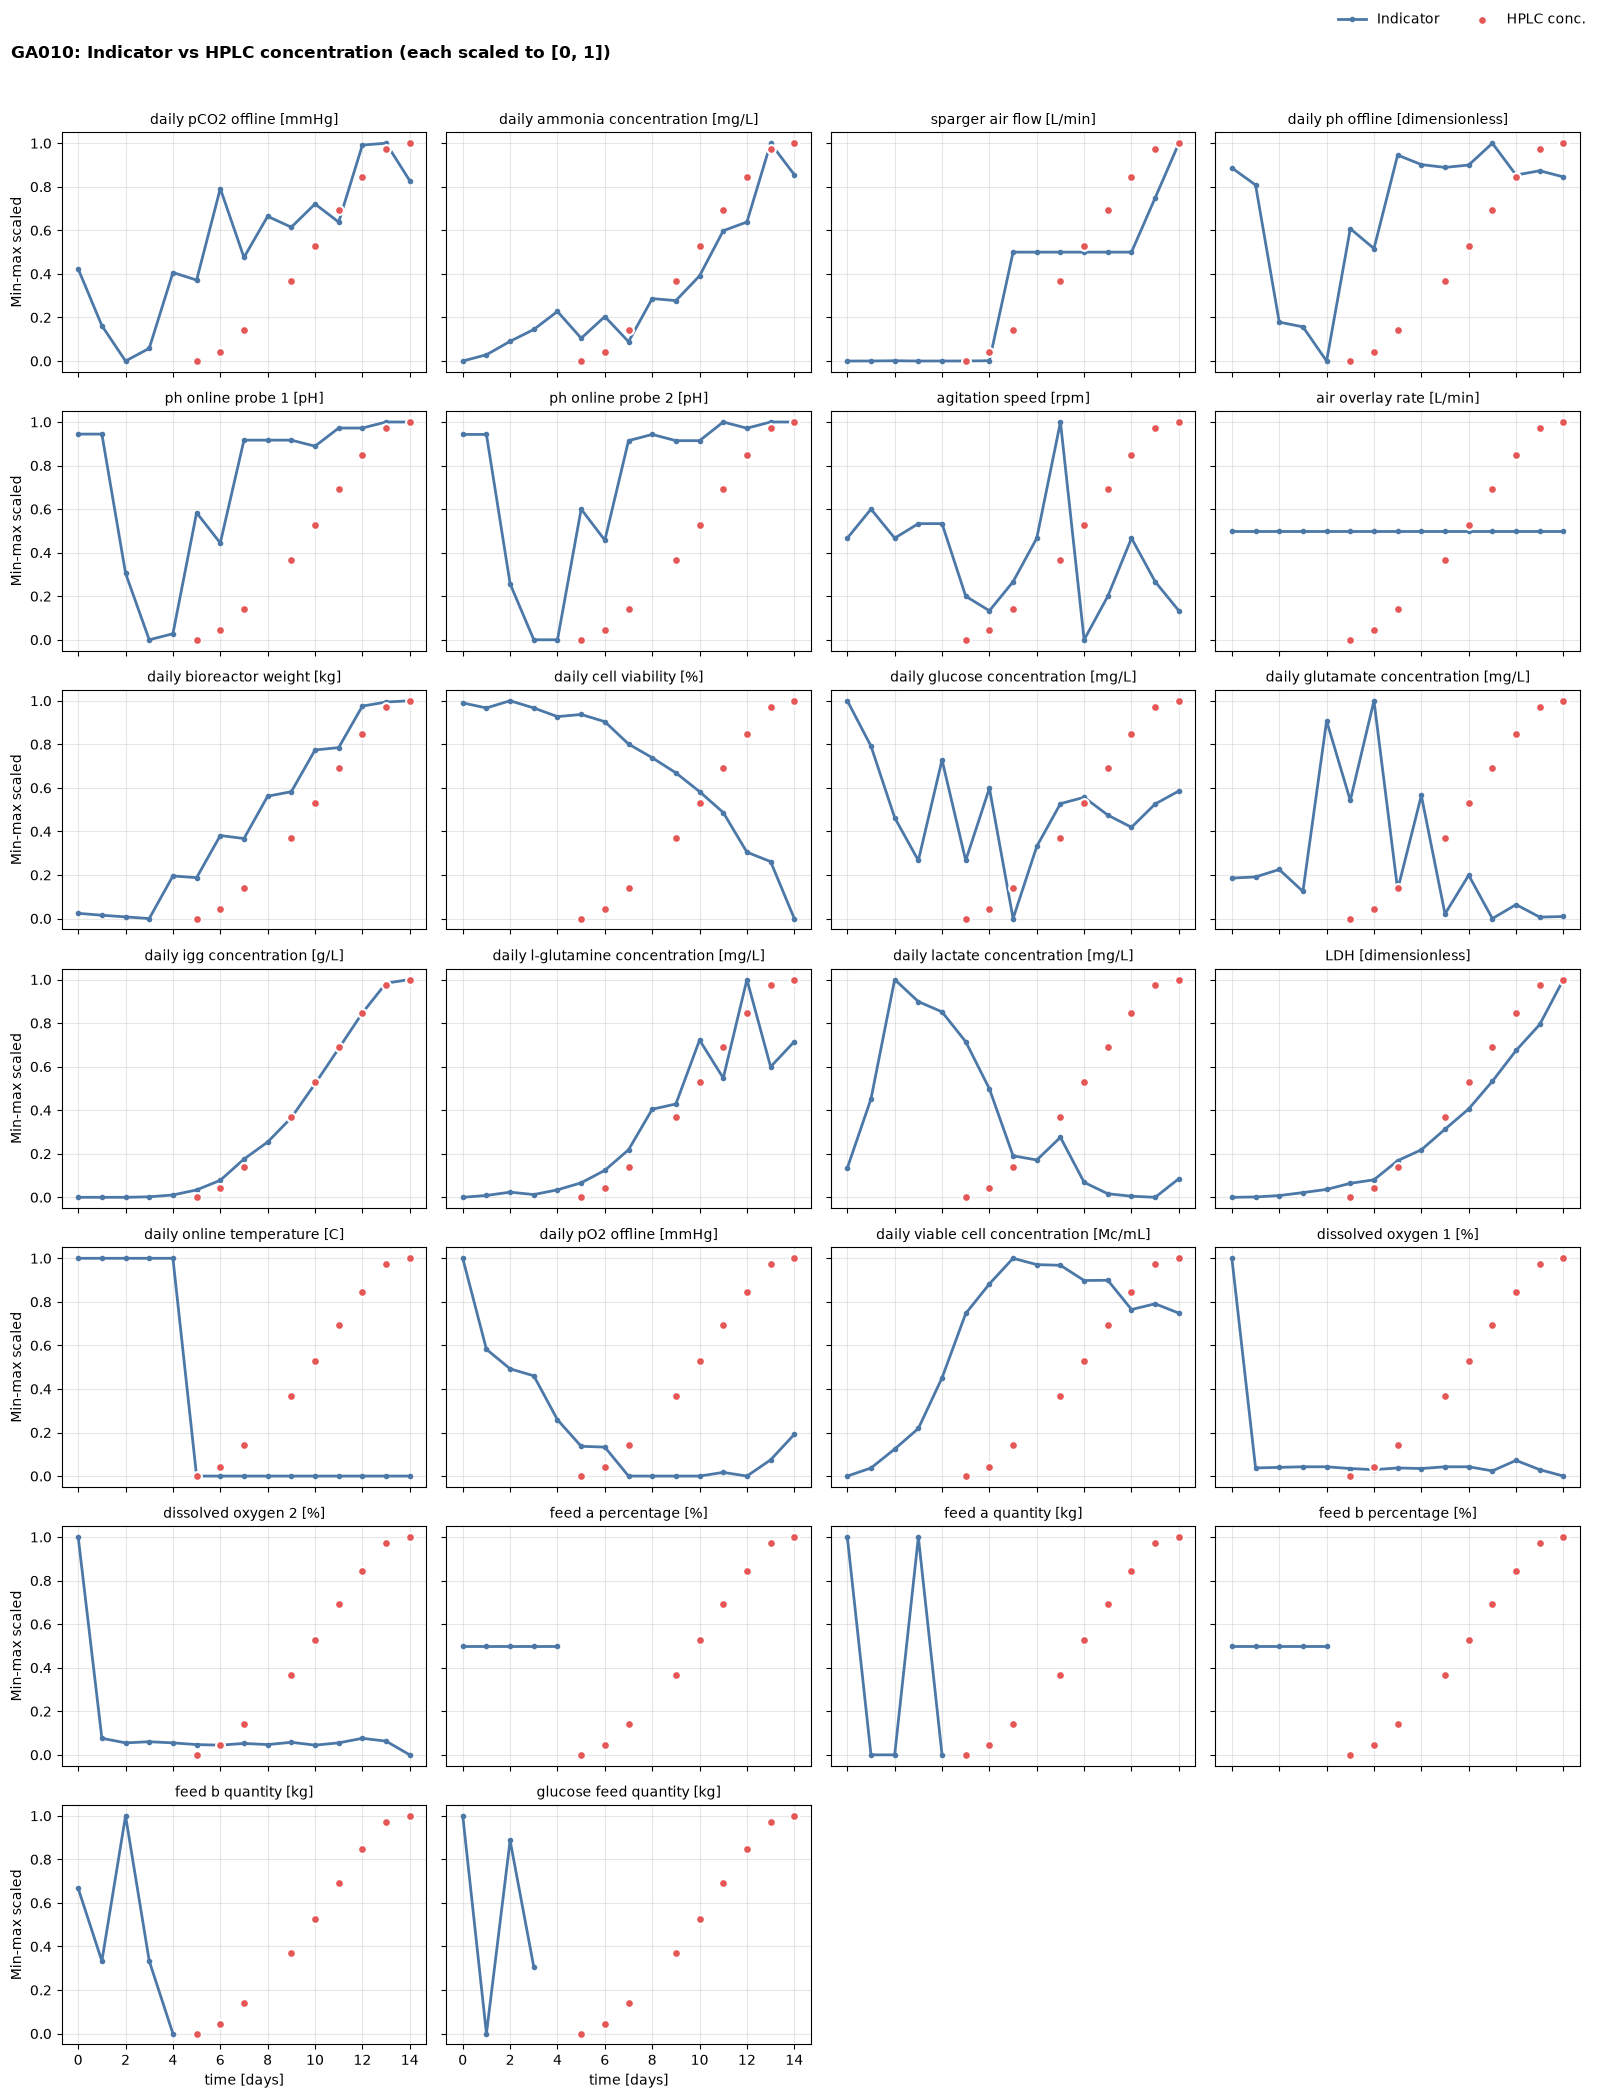

In [ ]:
TIME = "time [days]"
# TARGET = "HPLC_Concentration [mg/ml]"
TARGET = "daily igg concentration [g/L]"


def min_max(s):
    # Scale to [0, 1] so every indicator shares the HPLC axis; constant columns map to 0.5
    rng = s.max() - s.min()
    return (s - s.min()) / rng if rng else s * 0 + 0.5


def plot_run_vs_hplc(run_df, run_name, ncols = 4):
    indicators = [c for c in run_df.columns if c not in (TIME, TARGET) and run_df[c].notna().sum() > 1]
    nrows = -(-len(indicators) // ncols)
    fig, axs = plt.subplots(nrows, ncols, figsize = (4 * ncols, 3 * nrows), sharex = True, sharey = True)
    axs = axs.ravel()

    hplc = run_df[[TIME, TARGET]].dropna()
    hplc_scaled = min_max(hplc[TARGET])

    for ax, indicator in zip(axs, indicators):
        sub = run_df[[TIME, indicator]].dropna()
        ax.plot(sub[TIME], min_max(sub[indicator]), color = "#4C78A8", lw = 2, marker = "o", ms = 3, label = "Indicator")
        ax.scatter(hplc[TIME], hplc_scaled, color = "#E45756", s = 40, edgecolor = "white", lw = 1.5, zorder = 3, label = "HPLC conc.")
        ax.set_title(indicator, fontsize = 10)
        ax.grid(alpha = 0.3)

    for ax in axs[len(indicators):]:
        ax.set_visible(False)
    for ax in axs[-ncols:]:
        ax.set_xlabel(TIME)
    for ax in axs[::ncols]:
        ax.set_ylabel("Min-max scaled")

    handles, labels = axs[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc = "upper right", ncols = 2, frameon = False)
    fig.suptitle(f"{run_name.split('_')[0]}: Indicator vs HPLC concentration (each scaled to [0, 1])", x = 0.01, ha = "left", fontweight = "bold")
    fig.tight_layout(rect = (0, 0, 1, 0.97))
    return fig


run = uniq_runs[9]
plot_run_vs_hplc(final_records[run], run)
plt.show()

### All runs: correlation with HPLC concentration

Pearson correlation between each indicator and the HPLC concentration, computed per run over the
days where both are available (days 5-7 and 9-14). Rows are sorted by the mean correlation across runs.

/home/f250555/repos/platinium_batch/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3036: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/f250555/repos/platinium_batch/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3037: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


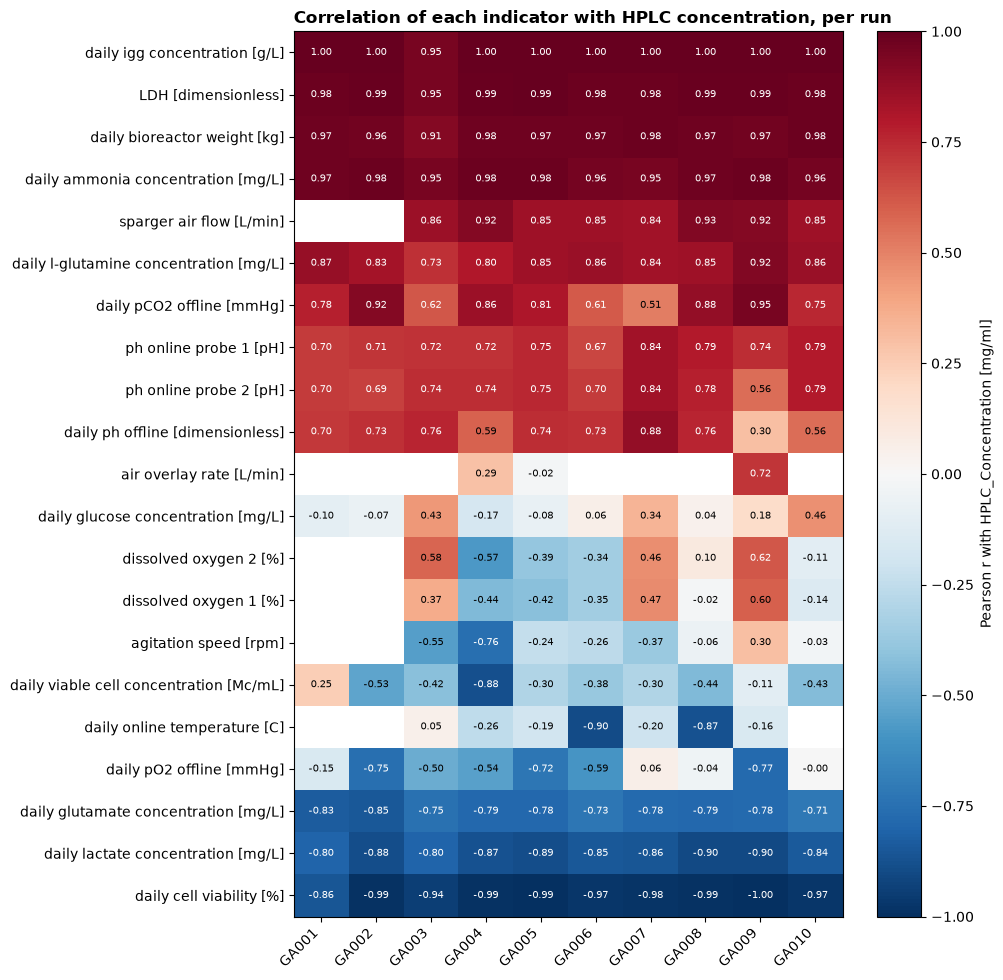

In [29]:
def plot_hplc_correlation(records):
    # One cell per (indicator, run): Pearson r between the indicator and HPLC on the days both were measured
    corr = pd.DataFrame({
        run.split("_")[0]: run_df.drop(columns = [TIME, TARGET]).corrwith(run_df[TARGET])
        for run, run_df in records.items()
    }).dropna(how = "all")
    corr = corr.loc[corr.mean(axis = 1).sort_values(ascending=False).index]

    fig, ax = plt.subplots(figsize = (10, 0.4 * len(corr) + 1.5))
    im = ax.imshow(corr, cmap = "RdBu_r", vmin = -1, vmax = 1, aspect = "auto")
    ax.set_xticks(range(corr.shape[1]), corr.columns, rotation = 45, ha = "right")
    ax.set_yticks(range(corr.shape[0]), corr.index)
    for (i, j), v in np.ndenumerate(corr.to_numpy()):
        if not np.isnan(v):
            ax.text(j, i, f"{v:.2f}", ha = "center", va = "center", fontsize = 7, color = "white" if abs(v) > 0.6 else "black")
    fig.colorbar(im, ax = ax, label = f"Pearson r with {TARGET}")
    ax.set_title("Correlation of each indicator with HPLC concentration, per run", loc = "left", fontweight = "bold")
    fig.tight_layout()
    return fig


plot_hplc_correlation(final_records)
plt.show()

# Titer Comparison by Campaign

In [30]:
df = pd.read_excel("./data/TGF N-prod data.xlsx", sheet_name = 1, header = 0)
df.head()

,Run,Process Time [h],agitation speed [rpm],air overlay rate [L/min],daily ammonia concentration [mg/L],daily bioreactor weight [kg],daily cell viability [%],daily glucose concentration [mg/L],daily glutamate concentration [mg/L],daily igg concentration [g/L],daily l-glutamine concentration [mg/L],daily lactate concentration [mg/L],LDH [dimensionless],daily online temperature [C],daily pCO2 offline [mmHg],daily ph offline [dimensionless],daily pO2 offline [mmHg],daily viable cell concentration [Mc/mL],dissolved oxygen 1 [%],dissolved oxygen 2 [%],feed a percentage [%],feed a quantity [kg],feed b percentage [%],feed b quantity [kg],glucose feed quantity [kg],ph online probe 1 [pH],ph online probe 2 [pH],sparger air flow [L/min]
0,GA001_TGFBxPD1 N STR2000L_1003472,70.585556,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.17,NaN,NaN
1,GA001_TGFBxPD1 N STR2000L_1003472,70.588056,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.19,NaN
2,GA001_TGFBxPD1 N STR2000L_1003472,70.817222,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.184,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,GA001_TGFBxPD1 N STR2000L_1003472,70.819444,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,65.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,GA001_TGFBxPD1 N STR2000L_1003472,70.821667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,142.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


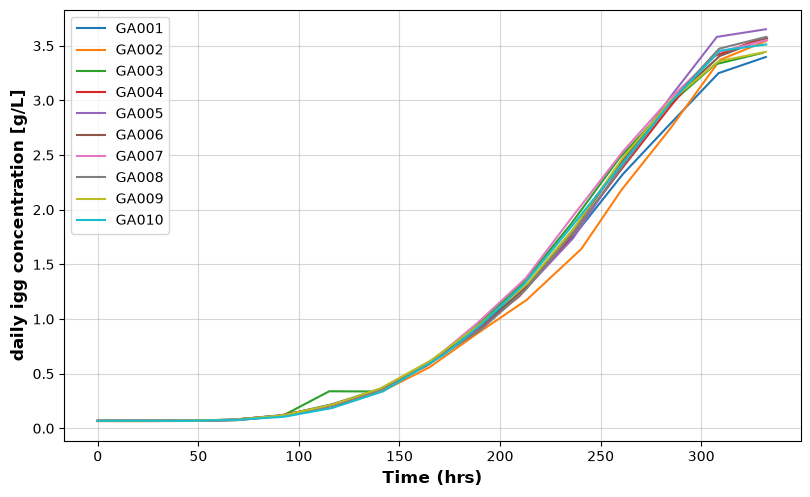

In [31]:
fig, ax = plt.subplots(figsize=(9.5, 5.6))

indicator = "daily igg concentration [g/L]"

for campaign in sorted(df["Run"].unique()):

    sub_df = df[df["Run"] == campaign][["Process Time [h]", indicator]].copy()
    sub_df = sub_df[~sub_df[indicator].isna()]
    ax.plot(sub_df["Process Time [h]"] - sub_df["Process Time [h]"].min(), sub_df[indicator], label = campaign.split("_")[0])

ax.set_xlabel("Time (hrs)", fontsize=12, fontweight='bold')
ax.set_ylabel(indicator, fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha = 0.5)